<a href="https://colab.research.google.com/github/cristiangaymartin/tfm-estados-mercado/blob/main/notebooks/04_overlay_historico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 · Overlay histórico

Lectura de los regímenes de mercado detectados por el HMM a la luz de los
acontecimientos históricos. Overlays del S&P 500 (hitos globales) y del IBEX 35
(cascada europea/española). Cuarta etapa, tras la clasificación de `03`.

In [1]:
%pip install hmmlearn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

In [3]:
from google.colab import drive
drive.mount('/content/drive')
RUTA_DATOS = "/content/drive/MyDrive/TFM/data"
RUTA_DOCS  = "/content/drive/MyDrive/TFM/docs"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
def detectar_regimenes(df, n_estados=4, random_state=42):
    """Detecta regímenes de mercado con HMM. Devuelve datos con columnas 'estado' y 'regimen'."""
    datos = df[["ret_log", "vol_21d"]].dropna().copy()
    scaler = StandardScaler()
    X = scaler.fit_transform(datos)
    modelo = hmm.GaussianHMM(n_components=n_estados, covariance_type="full",
                             n_iter=1000, random_state=random_state)
    modelo.fit(X)
    datos["estado"] = modelo.predict(X)
    nombres = ["Calma alcista", "Normal", "Corrección", "Crisis"][:n_estados]
    vol_por_estado = datos.groupby("estado")["vol_21d"].mean().sort_values()
    mapeo = {est: nom for est, nom in zip(vol_por_estado.index, nombres)}
    datos["regimen"] = datos["estado"].map(mapeo)
    return datos, modelo

# Cargamos el S&P y recalculamos sus regímenes
sp = pd.read_csv(f"{RUTA_DATOS}/mercado_SP500.csv", index_col=0, parse_dates=True)
sp_reg, _ = detectar_regimenes(sp)
print("S&P y regímenes listos:", sp_reg["regimen"].value_counts().to_dict())

S&P y regímenes listos: {'Calma alcista': 3763, 'Normal': 2661, 'Corrección': 1897, 'Crisis': 871}


In [5]:
# Cronología de eventos. Cada evento: nombre, tipo (línea/banda), fechas, y ámbito.
# 'ambito' nos permite filtrar qué eventos mostrar en cada overlay.
eventos = [
    # --- Globales (aplican a todos los mercados) ---
    {"nombre": "Estallido puntocom",        "tipo": "banda", "inicio": "2000-03-01", "fin": "2002-10-01", "ambito": "global"},
    {"nombre": "11-S",                       "tipo": "linea", "inicio": "2001-09-11", "fin": None,         "ambito": "global"},
    {"nombre": "Crisis financiera global",   "tipo": "banda", "inicio": "2007-08-01", "fin": "2009-06-01", "ambito": "global"},
    {"nombre": "COVID-19",                   "tipo": "linea", "inicio": "2020-03-01", "fin": None,         "ambito": "global"},
    {"nombre": "Inflación + guerra Ucrania", "tipo": "banda", "inicio": "2022-01-01", "fin": "2022-10-01", "ambito": "global"},
    {"nombre": "Crisis rusa / LTCM",         "tipo": "banda", "inicio": "1998-08-01", "fin": "1998-10-31", "ambito": "global"},

    # --- Europa / España (para IBEX y STOXX) ---
    {"nombre": "Crisis deuda europea",       "tipo": "banda", "inicio": "2010-05-01", "fin": "2012-09-01", "ambito": "europa"},
    {"nombre": "Rescate bancario español",   "tipo": "linea", "inicio": "2012-06-01", "fin": None,         "ambito": "europa"},
    {"nombre": "Brexit (referéndum)",        "tipo": "linea", "inicio": "2016-06-23", "fin": None,         "ambito": "europa"},

    # --- Asia (contexto, por si se usa en otros mercados) ---
    {"nombre": "Crisis China / petróleo", "tipo": "banda", "inicio": "2015-08-01", "fin": "2016-02-29", "ambito": "global"},
]

# Lo convertimos en DataFrame para manejarlo cómodamente
crono = pd.DataFrame(eventos)
crono["inicio"] = pd.to_datetime(crono["inicio"])
crono["fin"] = pd.to_datetime(crono["fin"])
print(f"Cronología con {len(crono)} eventos:")
print(crono[["nombre", "tipo", "inicio", "ambito"]].to_string(index=False))

Cronología con 10 eventos:
                    nombre  tipo     inicio ambito
        Estallido puntocom banda 2000-03-01 global
                      11-S linea 2001-09-11 global
  Crisis financiera global banda 2007-08-01 global
                  COVID-19 linea 2020-03-01 global
Inflación + guerra Ucrania banda 2022-01-01 global
        Crisis rusa / LTCM banda 1998-08-01 global
      Crisis deuda europea banda 2010-05-01 europa
  Rescate bancario español linea 2012-06-01 europa
       Brexit (referéndum) linea 2016-06-23 europa
   Crisis China / petróleo banda 2015-08-01 global


In [6]:
# Reutilizamos los regímenes del S&P (sp_reg) y le unimos el precio
overlay_sp = sp_reg.copy()
overlay_sp["Close"] = sp["Close"]

# Colores de los regímenes (la paleta de gravedad que ya usamos)
colores = {
    "Calma alcista": "#2ca02c",
    "Normal":        "#ffd92f",
    "Corrección":    "#ff7f0e",
    "Crisis":        "#d62728",
}

# Filtramos los eventos globales para este overlay
eventos_sp = crono[crono["ambito"] == "global"]
print(f"Eventos a mostrar en el overlay del S&P: {len(eventos_sp)}")
print(eventos_sp[["nombre", "tipo", "inicio"]].to_string(index=False))

Eventos a mostrar en el overlay del S&P: 7
                    nombre  tipo     inicio
        Estallido puntocom banda 2000-03-01
                      11-S linea 2001-09-11
  Crisis financiera global banda 2007-08-01
                  COVID-19 linea 2020-03-01
Inflación + guerra Ucrania banda 2022-01-01
        Crisis rusa / LTCM banda 1998-08-01
   Crisis China / petróleo banda 2015-08-01


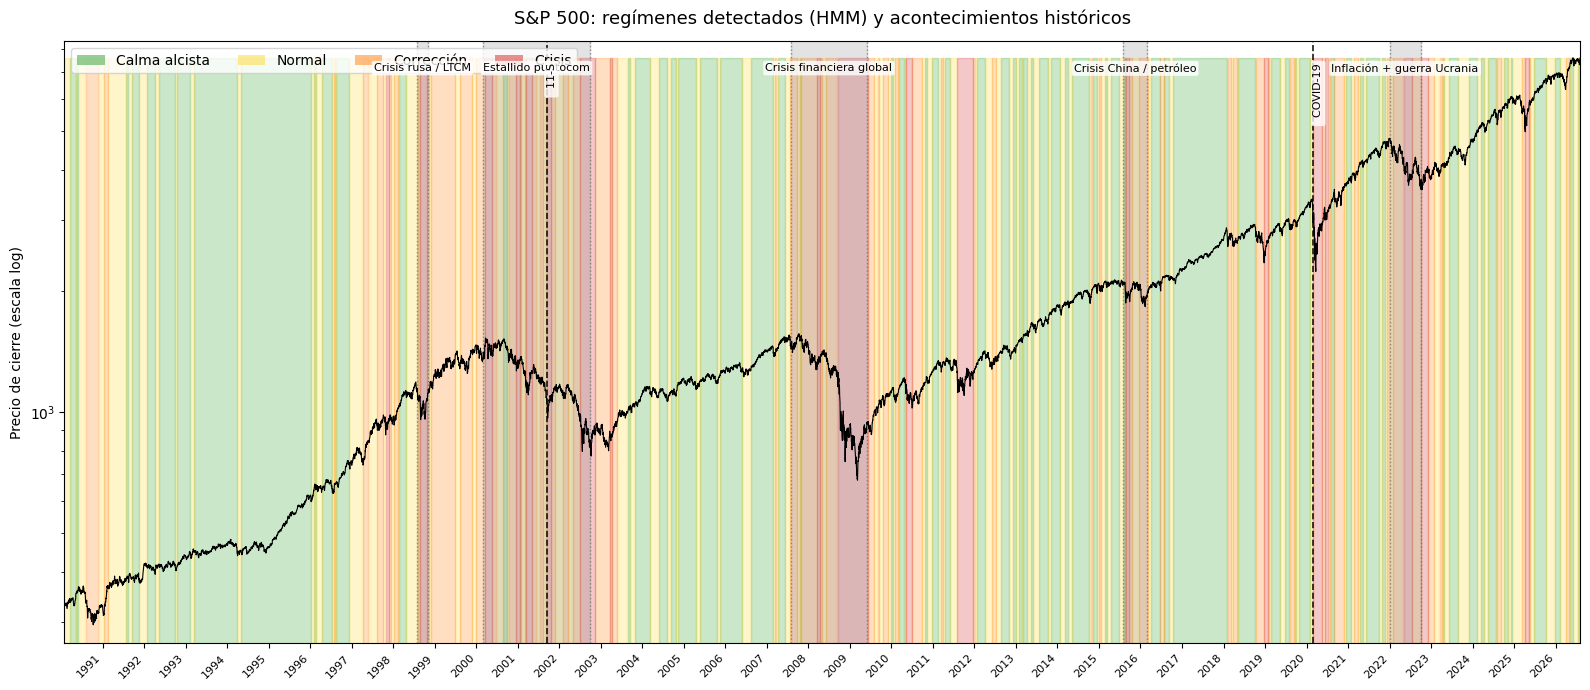

In [7]:
fig, ax = plt.subplots(figsize=(16, 7))

# Fondo: regímenes detectados por el HMM
ax.plot(overlay_sp.index, overlay_sp["Close"], color="black", linewidth=0.8, zorder=4)
for regimen, color in colores.items():
    mask = overlay_sp["regimen"] == regimen
    ax.fill_between(overlay_sp.index, 0, overlay_sp["Close"].max(),
                    where=mask, color=color, alpha=0.25, zorder=1)

# Eventos históricos encima
caja = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8)
ymax = overlay_sp["Close"].max()

for _, ev in eventos_sp.iterrows():
    if ev["tipo"] == "linea":
        ax.axvline(ev["inicio"], color="black", linestyle="--", linewidth=1.2, alpha=0.9, zorder=5)
        ax.text(ev["inicio"], ymax*0.97, "  " + ev["nombre"], rotation=90,
                fontsize=8, va="top", ha="left", color="black", zorder=6, bbox=caja)
    else:
        ax.axvspan(ev["inicio"], ev["fin"], color="dimgray", alpha=0.18, zorder=2)
        ax.axvline(ev["inicio"], color="dimgray", linestyle=":", linewidth=1, alpha=0.7, zorder=3)
        ax.axvline(ev["fin"],    color="dimgray", linestyle=":", linewidth=1, alpha=0.7, zorder=3)
        centro = ev["inicio"] + (ev["fin"] - ev["inicio"]) / 2
        ax.text(centro, ymax*0.97, ev["nombre"], rotation=0, ha="center", va="top",
                fontsize=8, color="black", zorder=6, bbox=caja)

ax.set_yscale("log")
ax.set_ylim(overlay_sp["Close"].min()*0.9, overlay_sp["Close"].max()*1.1)
ax.set_title("S&P 500: regímenes detectados (HMM) y acontecimientos históricos", fontsize=13, pad=12)
ax.set_ylabel("Precio de cierre (escala log)")
ax.legend(handles=[Patch(facecolor=c, alpha=0.5, label=r) for r, c in colores.items()],
          loc="upper left", ncol=4)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(overlay_sp.index.min(), overlay_sp.index.max())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{RUTA_DOCS}/overlay_sp500.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Cargamos el IBEX y calculamos sus regímenes
ibex = pd.read_csv(f"{RUTA_DATOS}/mercado_IBEX35.csv", index_col=0, parse_dates=True)
ibex_reg, _ = detectar_regimenes(ibex)
overlay_ibex = ibex_reg.copy()
overlay_ibex["Close"] = ibex["Close"]

print("IBEX y regímenes listos:", ibex_reg["regimen"].value_counts().to_dict())
print("Rango:", overlay_ibex.index.min().date(), "→", overlay_ibex.index.max().date())

# Eventos para el IBEX: globales + europeos
eventos_ibex = crono[crono["ambito"].isin(["global", "europa"])]
print(f"\nEventos a mostrar en el overlay del IBEX: {len(eventos_ibex)}")
print(eventos_ibex[["nombre", "tipo", "inicio"]].to_string(index=False))

IBEX y regímenes listos: {'Calma alcista': 2596, 'Normal': 2407, 'Corrección': 2200, 'Crisis': 1153}
Rango: 1993-08-10 → 2026-08-03

Eventos a mostrar en el overlay del IBEX: 10
                    nombre  tipo     inicio
        Estallido puntocom banda 2000-03-01
                      11-S linea 2001-09-11
  Crisis financiera global banda 2007-08-01
                  COVID-19 linea 2020-03-01
Inflación + guerra Ucrania banda 2022-01-01
        Crisis rusa / LTCM banda 1998-08-01
      Crisis deuda europea banda 2010-05-01
  Rescate bancario español linea 2012-06-01
       Brexit (referéndum) linea 2016-06-23
   Crisis China / petróleo banda 2015-08-01


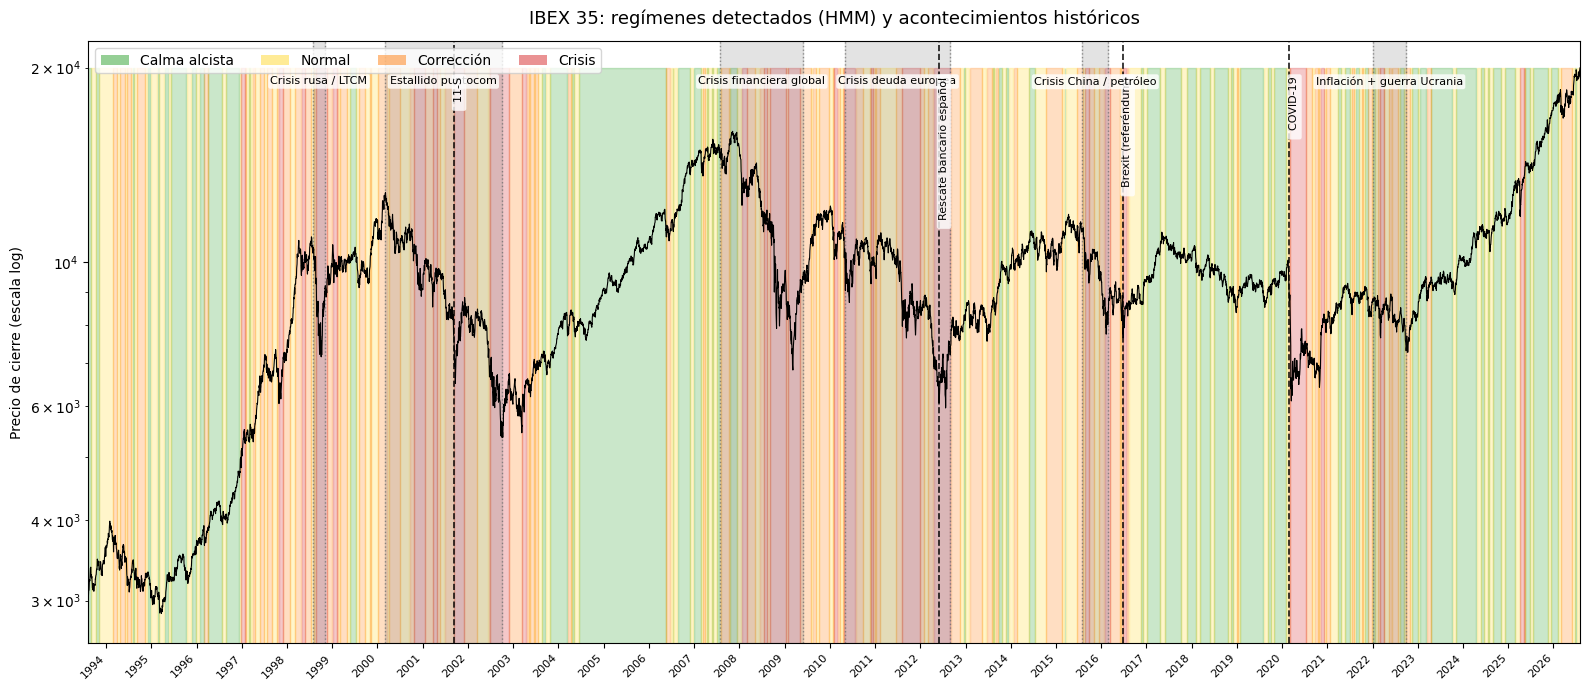

In [9]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(overlay_ibex.index, overlay_ibex["Close"], color="black", linewidth=0.8, zorder=4)
for regimen, color in colores.items():
    mask = overlay_ibex["regimen"] == regimen
    ax.fill_between(overlay_ibex.index, 0, overlay_ibex["Close"].max(),
                    where=mask, color=color, alpha=0.25, zorder=1)

caja = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8)
ymax = overlay_ibex["Close"].max()

for _, ev in eventos_ibex.iterrows():
    if ev["tipo"] == "linea":
        ax.axvline(ev["inicio"], color="black", linestyle="--", linewidth=1.2, alpha=0.9, zorder=5)
        ax.text(ev["inicio"], ymax*0.97, "  " + ev["nombre"], rotation=90,
                fontsize=8, va="top", ha="left", color="black", zorder=6, bbox=caja)
    else:
        ax.axvspan(ev["inicio"], ev["fin"], color="dimgray", alpha=0.18, zorder=2)
        ax.axvline(ev["inicio"], color="dimgray", linestyle=":", linewidth=1, alpha=0.7, zorder=3)
        ax.axvline(ev["fin"],    color="dimgray", linestyle=":", linewidth=1, alpha=0.7, zorder=3)
        centro = ev["inicio"] + (ev["fin"] - ev["inicio"]) / 2
        ax.text(centro, ymax*0.97, ev["nombre"], rotation=0, ha="center", va="top",
                fontsize=8, color="black", zorder=6, bbox=caja)

ax.set_yscale("log")
ax.set_ylim(overlay_ibex["Close"].min()*0.9, overlay_ibex["Close"].max()*1.1)
ax.set_xlim(overlay_ibex.index.min(), overlay_ibex.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_title("IBEX 35: regímenes detectados (HMM) y acontecimientos históricos", fontsize=13, pad=12)
ax.set_ylabel("Precio de cierre (escala log)")
ax.legend(handles=[Patch(facecolor=c, alpha=0.5, label=r) for r, c in colores.items()],
          loc="upper left", ncol=4)
plt.tight_layout()
plt.savefig(f"{RUTA_DOCS}/overlay_ibex35.png", dpi=150, bbox_inches="tight")
plt.show()

## Overlay del STOXX 600

El STOXX 600 dispone de datos desde 2004, por lo que los acontecimientos
anteriores (estallido puntocom, 11-S, crisis rusa/LTCM) quedan fuera de su
rango temporal y se excluyen de este overlay. Se muestran únicamente los
eventos globales y europeos posteriores a 2004, evitando así anotar periodos
para los que no se dispone de datos.

In [10]:
# Cargamos el STOXX 600 y calculamos sus regímenes
stoxx = pd.read_csv(f"{RUTA_DATOS}/mercado_STOXX600.csv", index_col=0, parse_dates=True)
stoxx_reg, _ = detectar_regimenes(stoxx)
overlay_stoxx = stoxx_reg.copy()
overlay_stoxx["Close"] = stoxx["Close"]

inicio_stoxx = overlay_stoxx.index.min()
print("STOXX y regímenes listos. Rango:", inicio_stoxx.date(), "→", overlay_stoxx.index.max().date())

# Eventos globales + europeos, PERO solo los que caen dentro del rango del STOXX (desde 2004)
eventos_stoxx = crono[
    (crono["ambito"].isin(["global", "europa"])) &
    (crono["inicio"] >= inicio_stoxx)
]
print(f"\nEventos dentro del rango del STOXX: {len(eventos_stoxx)}")
print(eventos_stoxx[["nombre", "tipo", "inicio"]].to_string(index=False))

STOXX y regímenes listos. Rango: 2004-05-25 → 2026-08-03

Eventos dentro del rango del STOXX: 7
                    nombre  tipo     inicio
  Crisis financiera global banda 2007-08-01
                  COVID-19 linea 2020-03-01
Inflación + guerra Ucrania banda 2022-01-01
      Crisis deuda europea banda 2010-05-01
  Rescate bancario español linea 2012-06-01
       Brexit (referéndum) linea 2016-06-23
   Crisis China / petróleo banda 2015-08-01


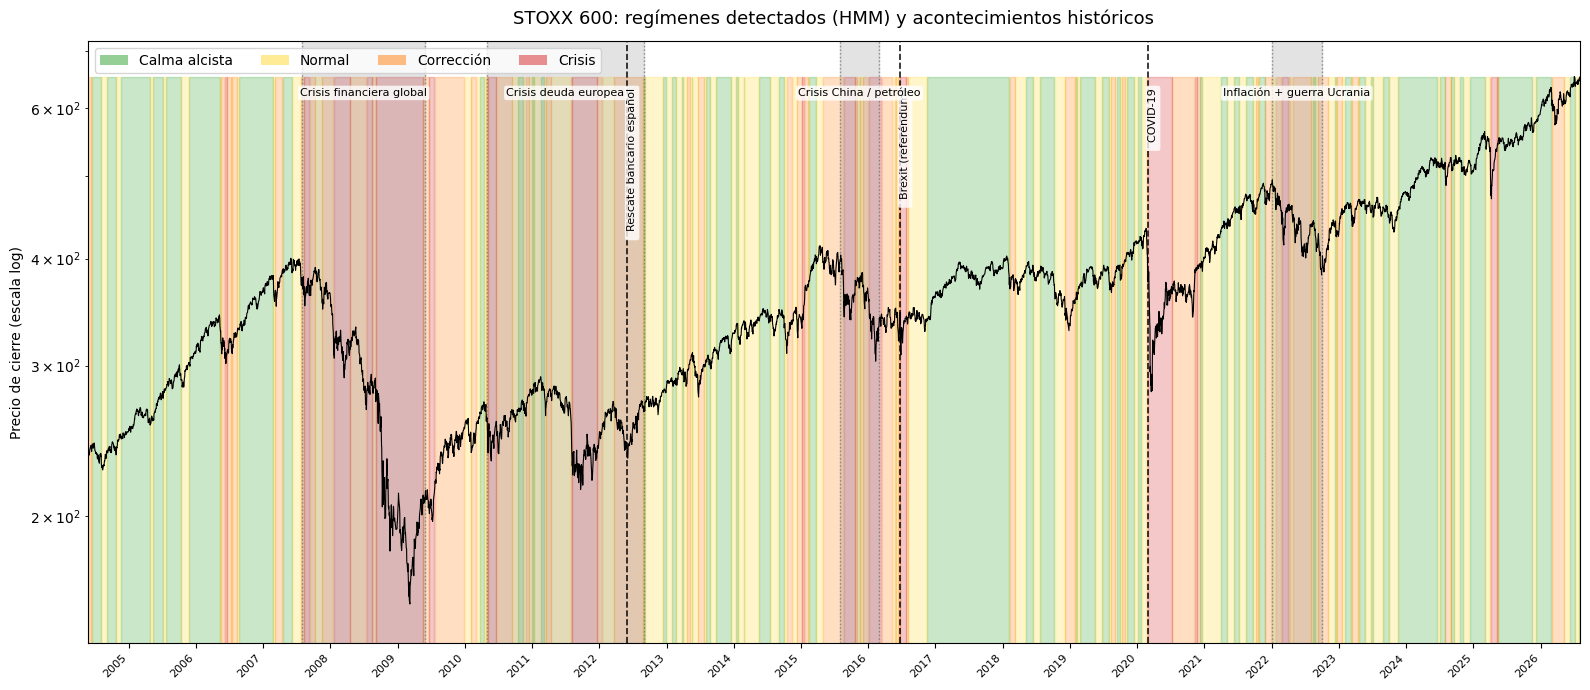

In [11]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(overlay_stoxx.index, overlay_stoxx["Close"], color="black", linewidth=0.8, zorder=4)
for regimen, color in colores.items():
    mask = overlay_stoxx["regimen"] == regimen
    ax.fill_between(overlay_stoxx.index, 0, overlay_stoxx["Close"].max(),
                    where=mask, color=color, alpha=0.25, zorder=1)

caja = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8)
ymax = overlay_stoxx["Close"].max()
for _, ev in eventos_stoxx.iterrows():
    if ev["tipo"] == "linea":
        ax.axvline(ev["inicio"], color="black", linestyle="--", linewidth=1.2, alpha=0.9, zorder=5)
        ax.text(ev["inicio"], ymax*0.97, "  " + ev["nombre"], rotation=90,
                fontsize=8, va="top", ha="left", color="black", zorder=6, bbox=caja)
    else:
        ax.axvspan(ev["inicio"], ev["fin"], color="dimgray", alpha=0.18, zorder=2)
        ax.axvline(ev["inicio"], color="dimgray", linestyle=":", linewidth=1, alpha=0.7, zorder=3)
        ax.axvline(ev["fin"],    color="dimgray", linestyle=":", linewidth=1, alpha=0.7, zorder=3)
        centro = ev["inicio"] + (ev["fin"] - ev["inicio"]) / 2
        ax.text(centro, ymax*0.97, ev["nombre"], rotation=0, ha="center", va="top",
                fontsize=8, color="black", zorder=6, bbox=caja)

ax.set_yscale("log")
ax.set_ylim(overlay_stoxx["Close"].min()*0.9, overlay_stoxx["Close"].max()*1.1)
ax.set_xlim(overlay_stoxx.index.min(), overlay_stoxx.index.max())
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_title("STOXX 600: regímenes detectados (HMM) y acontecimientos históricos", fontsize=13, pad=12)
ax.set_ylabel("Precio de cierre (escala log)")
ax.legend(handles=[Patch(facecolor=c, alpha=0.5, label=r) for r, c in colores.items()],
          loc="upper left", ncol=4)
plt.tight_layout()
plt.savefig(f"{RUTA_DOCS}/overlay_stoxx600.png", dpi=150, bbox_inches="tight")
plt.show()